In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [226]:
df = pd.read_csv("../data/feat/go_emotions_with_features.csv")

df.columns.tolist()

['UNCLEAN_TEXT_PT',
 'BASE_TEXT_PT',
 'admiration',
 'amusement',
 'anger',
 'annoyance',
 'approval',
 'caring',
 'confusion',
 'curiosity',
 'desire',
 'disappointment',
 'disapproval',
 'disgust',
 'embarrassment',
 'excitement',
 'fear',
 'gratitude',
 'grief',
 'joy',
 'love',
 'nervousness',
 'optimism',
 'pride',
 'realization',
 'relief',
 'remorse',
 'sadness',
 'surprise',
 'neutral',
 'id',
 'text',
 'UNCLEAN_TEXT_EN',
 'BASE_TEXT_EN',
 'doc',
 'n_words',
 'n_sentences',
 'words_per_sentence',
 'n_characters',
 'reading_time',
 'uppercase_ratio',
 'char_repetition_ratio',
 'avg_letters_per_word',
 'avg_syllables_per_word',
 'total_punct',
 'punct_per_word',
 'punct_per_sentence',
 'exclam',
 'quest',
 'rarest_word',
 'most_common_word',
 'avg_freq',
 'freq_disp',
 'ttr',
 'stopword_ratio',
 'n_unique_words',
 'mean_unique_word_length',
 'flesch_portuguese',
 'NOUN',
 'VERB',
 'ADJ',
 'ADV',
 'PRON',
 'DET',
 'ADP',
 'AUX',
 'CCONJ',
 'SCONJ',
 'NUM',
 'PROPN',
 'INTJ',
 'mea

## Configurations

In [218]:
df = pd.read_csv("../data/feat/go_emotions_with_features.csv")

emotion_cols = [
    'admiration','amusement','anger','annoyance','approval',
    'caring','confusion','curiosity','desire','disappointment',
    'disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness','optimism',
    'pride','realization','relief','remorse','sadness','surprise','neutral'
]

feature = ['passive_voice_ratio']

## Individual Analisys

In [219]:
desc = df[feature].describe()
desc

,passive_voice_ratio
count,54234.000000
mean,0.036864
std,0.169163
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


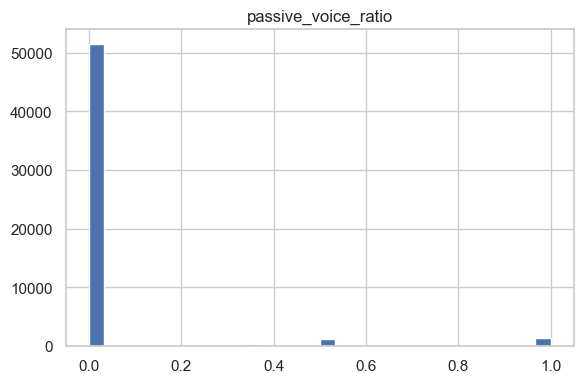

In [220]:
df[feature].hist(bins=30, figsize=(6,4))
plt.tight_layout()
plt.show()

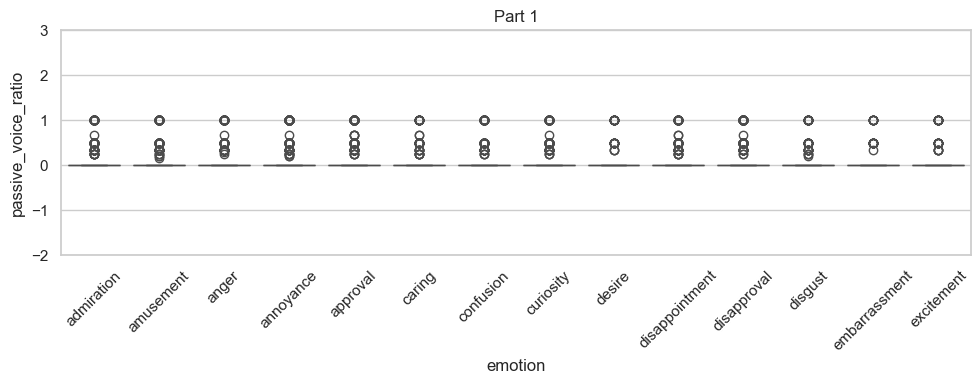

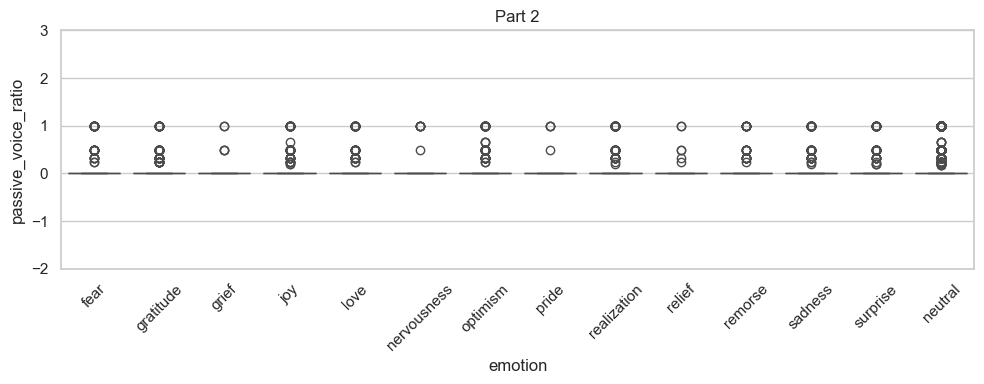

In [221]:
df_long = df.melt(
    id_vars=feature,
    value_vars=emotion_cols,
    var_name='emotion',
    value_name='label'
)

df_long = df_long[df_long['label'] == 1]

y_min = -2.0
y_max = 3.0

chunks = np.array_split(emotion_cols, 2)

for i, chunk in enumerate(chunks):
    plt.figure(figsize=(10,4))
    
    sns.boxplot(
        data=df_long[df_long['emotion'].isin(chunk)],
        x='emotion',
        y=feature[0]
    )
    
    plt.ylim(y_min, y_max)
    
    plt.xticks(rotation=45)
    plt.title(f'Part {i+1}')
    plt.tight_layout()
    plt.show()

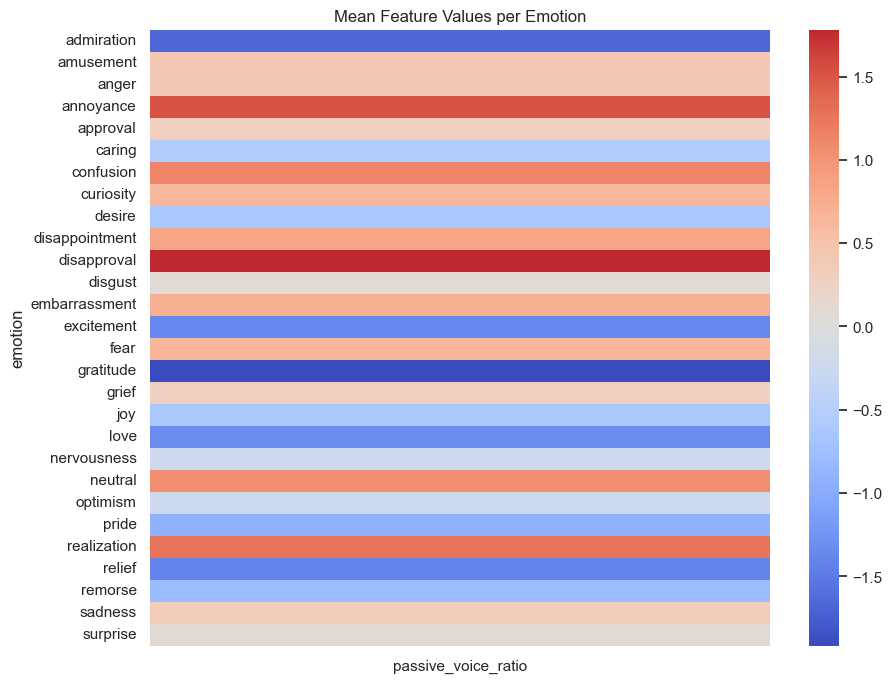

In [222]:
emotion_means = df_long.groupby('emotion')[feature].mean()
emotion_means_z = (emotion_means - emotion_means.mean()) / emotion_means.std()

plt.figure(figsize=(10,8))
sns.heatmap(emotion_means_z, cmap='coolwarm', center=0)
plt.title("Mean Feature Values per Emotion")
plt.show()

In [223]:
results = {}

def evaluate_feature(row):
    if row['p_anova'] < 0.05 and row['p_kruskal'] < 0.05:
        if row['eta_squared'] >= 0.06:
            return 'keep (medium effect)'
        elif row['eta_squared'] >= 0.01:
            return 'weak keep'
        else:
            return 'discard (tiny effect)'
    
    return 'discard (not significant)'

for feat in feature:
    
    # grupos por emoção
    groups = [
        df[df[emotion] == 1][feat].dropna()
        for emotion in emotion_cols
    ]
    
    # remove grupos vazios (importante!)
    groups = [g for g in groups if len(g) > 0]
    
    k = len(groups)                      # número de grupos
    n = sum(len(g) for g in groups)      # total de observações
    
    # --- ANOVA ---
    f_stat, p_anova = f_oneway(*groups)
    
    # --- ETA SQUARED ---
    eta_sq = (f_stat * (k - 1)) / (f_stat * (k - 1) + (n - k))
    
    # --- KRUSKAL (não-paramétrico) ---
    h_stat, p_kruskal = kruskal(*groups)
    
    results[feat] = {
        'p_anova': p_anova,
        'eta_squared': eta_sq,
        'p_kruskal': p_kruskal
    }

anova_df = pd.DataFrame(results).T
anova_df = anova_df.sort_values('p_anova')

anova_df['decision'] = anova_df.apply(evaluate_feature, axis=1)

anova_df

,p_anova,eta_squared,p_kruskal,decision
passive_voice_ratio,2.314590e-41,0.004181,1.490706e-38,discard (tiny effect)


## Groupal Analisys

In [227]:
features = [
    'n_words', 'words_per_sentence', 'reading_time', 'uppercase_ratio', 'avg_letters_per_word',
    'rarest_word', 'most_common_word', 'avg_freq', 'freq_disp', 'stopword_ratio', 'n_unique_words',
    'mean_verbs_per_sentence', 'mean_dependency_tree_depth', 'lexical_ambiguity', 'lexical_entropy', 
    'root_verb_position', 'dependency_pattern_diversity', 'mean_subtree_size', 'density'
]

desc = df[features].describe()
desc

,n_words,words_per_sentence,reading_time,uppercase_ratio,avg_letters_per_word,rarest_word,most_common_word,avg_freq,freq_disp,stopword_ratio,n_unique_words,mean_verbs_per_sentence,mean_dependency_tree_depth,lexical_ambiguity,lexical_entropy,root_verb_position,dependency_pattern_diversity,mean_subtree_size,density
count,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000,54234.000000
mean,15.310267,10.233970,0.058886,0.068043,4.580766,3.290497,7.291343,5.651704,1.240704,0.558244,11.956743,1.396012,3.847125,1.952671,2.271324,0.237351,12.159973,2.666884,0.182200
std,7.972206,5.927295,0.030662,0.121720,1.133827,1.273103,0.596067,0.500279,0.400607,0.159414,6.135557,1.184229,1.372689,1.089400,0.627128,0.204519,5.486731,0.673765,0.147000
min,1.000000,1.000000,0.003846,0.000000,1.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,9.000000,6.000000,0.034615,0.020408,4.034483,2.720000,7.100000,5.460440,1.019624,0.500000,7.000000,0.500000,3.000000,1.235294,1.945910,0.076923,8.000000,2.187500,0.090476
50%,15.000000,9.000000,0.057692,0.036145,4.500000,3.500000,7.470000,5.733550,1.222925,0.571429,12.000000,1.000000,3.666667,1.800000,2.397895,0.197832,12.000000,2.590909,0.131868
75%,21.000000,13.000000,0.080769,0.068966,5.000000,4.090000,7.680000,5.950000,1.445244,0.666667,17.000000,2.000000,4.500000,2.500000,2.751667,0.340659,16.000000,3.055556,0.214286
max,351.000000,46.000000,1.350000,1.000000,111.000000,7.440000,7.680000,7.455000,3.735000,1.000000,34.000000,10.000000,14.000000,16.000000,3.472415,0.966667,92.000000,7.257143,1.000000


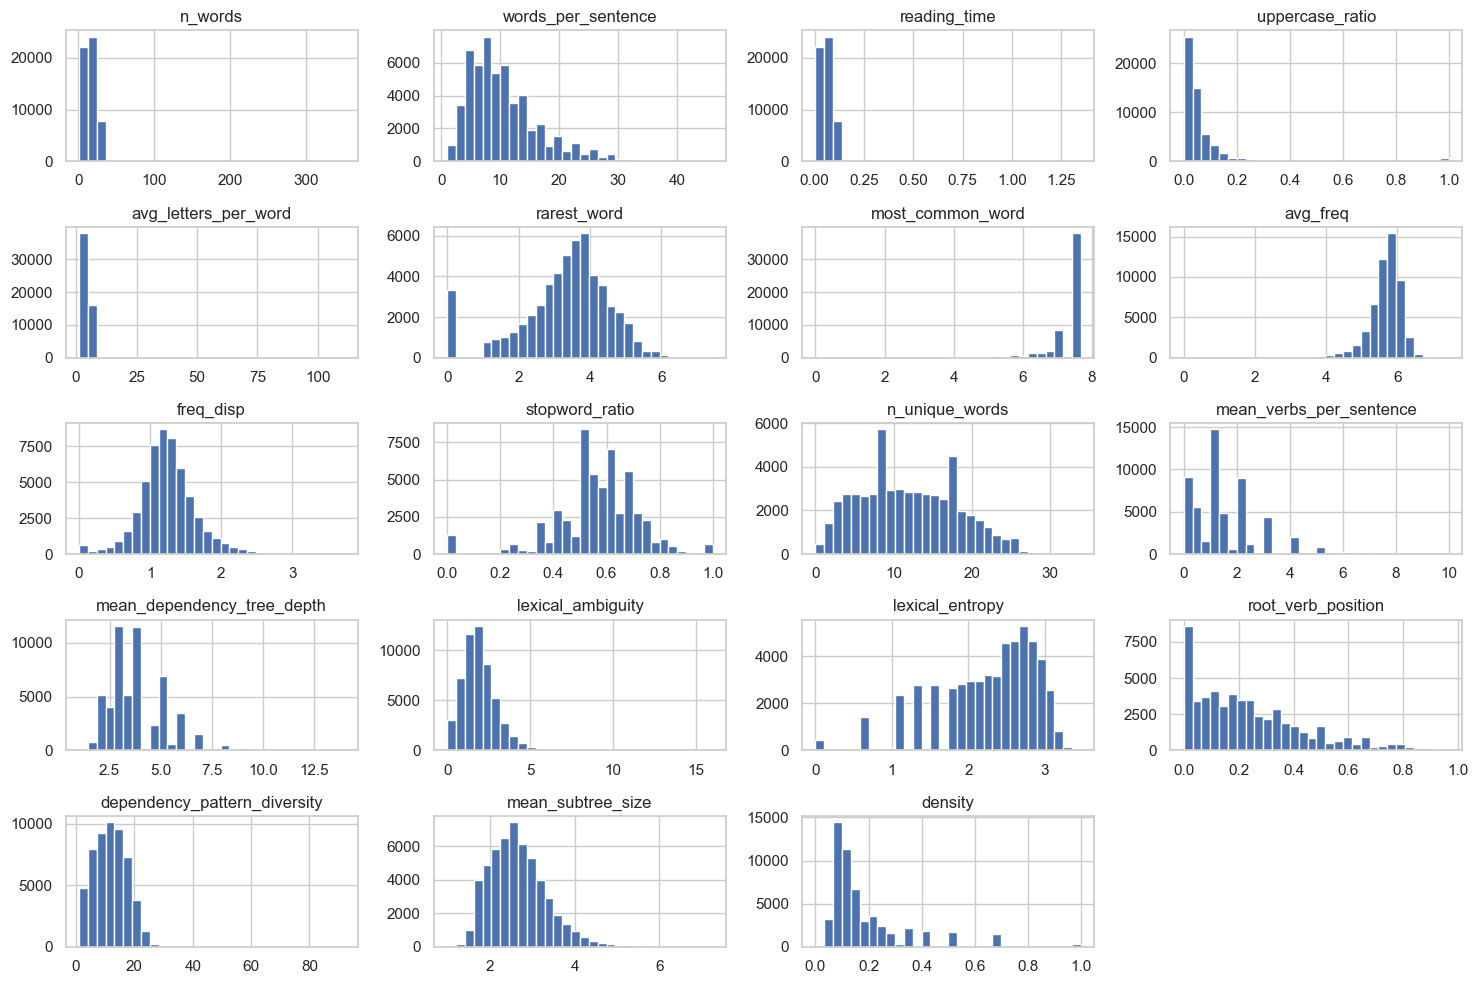

In [228]:
df[features].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

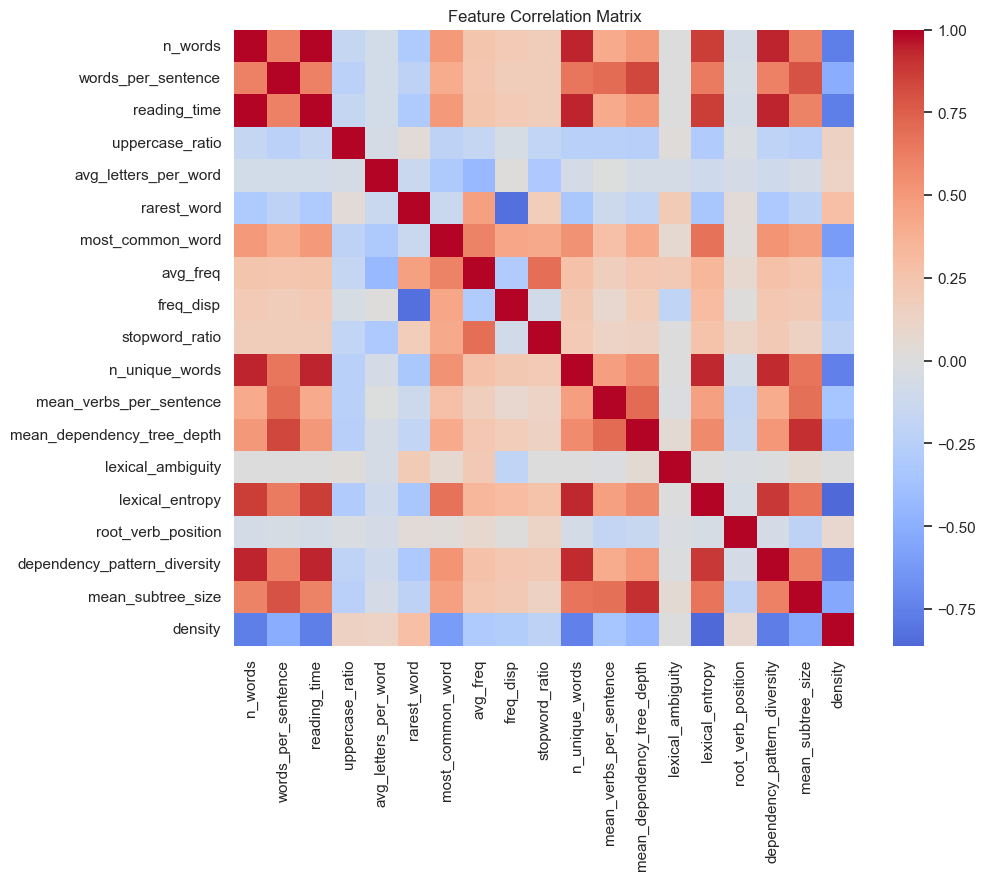

In [229]:
corr = df[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [230]:
emotion_cols = [
    'admiration','amusement','anger','annoyance','approval',
    'caring','confusion','curiosity','desire','disappointment',
    'disapproval','disgust','embarrassment','excitement','fear',
    'gratitude','grief','joy','love','nervousness','optimism',
    'pride','realization','relief','remorse','sadness','surprise','neutral'
]

df_long = df.melt(
    id_vars=features,
    value_vars=emotion_cols,
    var_name='emotion',
    value_name='label'
)

df_long = df_long[df_long['label'] == 1]

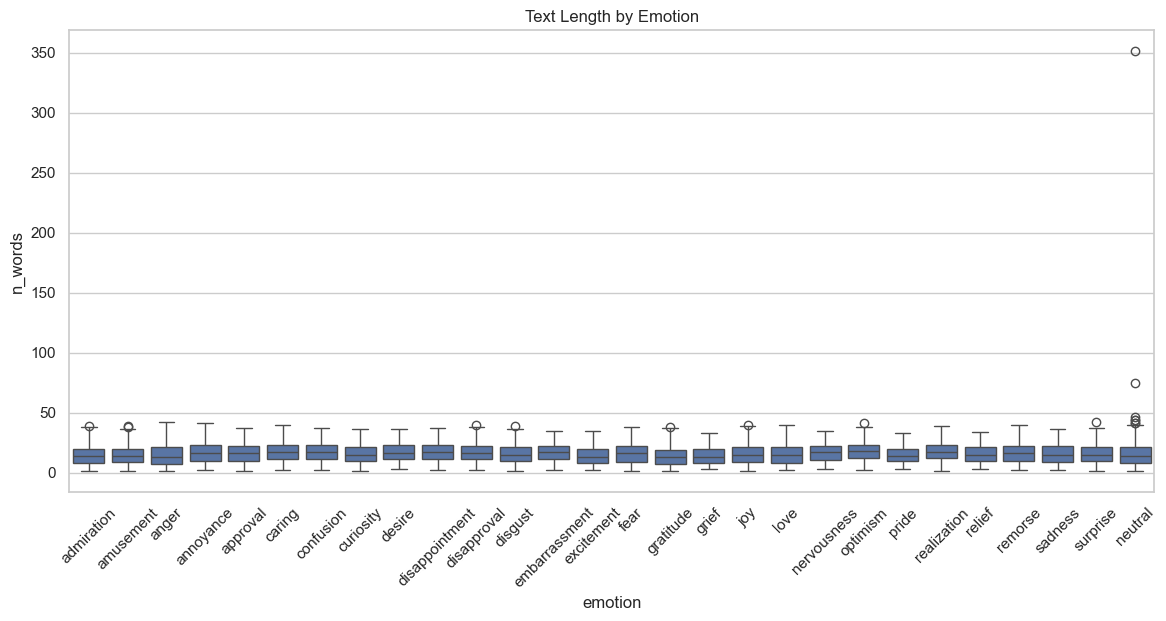

In [231]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_long, x='emotion', y='n_words')
plt.xticks(rotation=45)
plt.title("Text Length by Emotion")
plt.show()

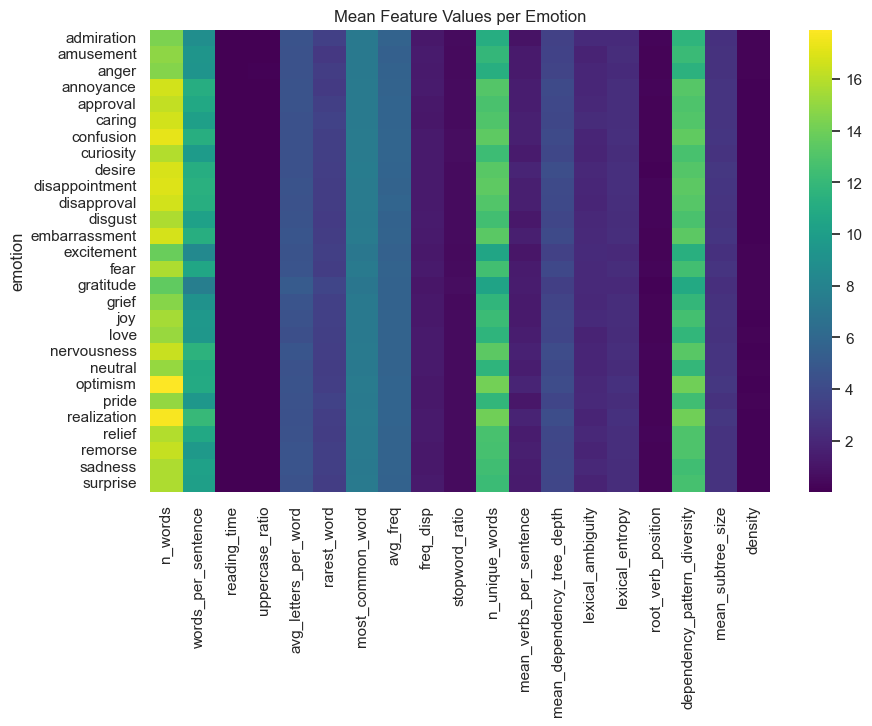

In [233]:
emotion_means = df_long.groupby('emotion')[features].mean()

plt.figure(figsize=(10,6))
sns.heatmap(emotion_means, cmap="viridis")
plt.title("Mean Feature Values per Emotion")
plt.show()

In [234]:
from scipy.stats import f_oneway

results = {}

for feature in features:
    groups = [
        df[df[emotion] == 1][feature].dropna()
        for emotion in emotion_cols
    ]
    
    f, p = f_oneway(*groups)
    results[feature] = p

anova_df = pd.DataFrame.from_dict(results, orient='index', columns=['p_value'])
anova_df.sort_values('p_value', inplace=True)

print(anova_df)

                                    p_value
words_per_sentence             0.000000e+00
mean_verbs_per_sentence        0.000000e+00
stopword_ratio                 0.000000e+00
lexical_entropy                0.000000e+00
mean_dependency_tree_depth     0.000000e+00
freq_disp                      0.000000e+00
mean_subtree_size             5.251267e-303
avg_freq                      7.511697e-301
n_unique_words                5.281712e-289
most_common_word              2.885574e-275
dependency_pattern_diversity  3.003501e-267
density                       1.415339e-257
root_verb_position            1.023982e-241
reading_time                  5.336823e-223
n_words                       5.336823e-223
avg_letters_per_word          1.227197e-208
uppercase_ratio               5.410730e-197
rarest_word                   1.478946e-186
lexical_ambiguity             4.277003e-160


In [235]:
top_features = emotion_means.std().sort_values(ascending=False).head(10)

print(top_features)

n_words                         1.105286
words_per_sentence              1.048713
n_unique_words                  0.963370
dependency_pattern_diversity    0.799415
mean_verbs_per_sentence         0.224813
mean_dependency_tree_depth      0.223744
rarest_word                     0.150110
avg_letters_per_word            0.137302
lexical_ambiguity               0.136701
mean_subtree_size               0.107484
dtype: float64
